<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Time-Series-and-Forecasting/TimeSeriesAndForecasting/Forecast_Decay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# 1. SETUP & DATA INGESTION
# ==========================================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

In [2]:
# Settings
SEQ_LEN = 60          # Lookback Window
MAX_HORIZON = 10      # Predict 1 to 10 days ahead
SPLIT_RATIO = 0.80

In [4]:
# Download Data
tickers = {
    'SPY': 'SPY',         # Market
    'VIX': '^VIX',        # Fear
    '10Y': '^TNX',        # Rates
    'DXY': 'DX-Y.NYB',    # Dollar
    'OIL': 'CL=F'         # Commodity
}

print("📥 Downloading Data...")
raw_df = yf.download(list(tickers.values()), start='2005-01-01', end='2024-01-01', progress=False, auto_adjust=False)['Adj Close']
raw_df.columns = tickers.keys()
raw_df.ffill(inplace=True)
raw_df.dropna(inplace=True)

raw_df.head()

📥 Downloading Data...


,SPY,VIX,10Y,DXY,OIL
Date,,,,,
2005-01-03,42.119999,81.300003,81.605980,4.220,14.08
2005-01-04,43.910000,82.570000,80.608826,4.283,13.98
2005-01-05,43.389999,82.540001,80.052551,4.277,14.09
2005-01-06,45.560001,83.150002,80.459564,4.272,13.58
2005-01-07,45.430000,83.610001,80.344238,4.285,13.49


In [5]:
# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
df = pd.DataFrame()

# A. Create Stationary Features (For the AI)
df['SPY_Ret'] = np.log(raw_df['SPY'] / raw_df['SPY'].shift(1))
df['VIX_Diff'] = raw_df['VIX'].diff()
df['10Y_Diff'] = raw_df['10Y'].diff()
df['DXY_Ret'] = np.log(raw_df['DXY'] / raw_df['DXY'].shift(1))
df['OIL_Ret'] = np.log(raw_df['OIL'] / raw_df['OIL'].shift(1))

df.head()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,SPY_Ret,VIX_Diff,10Y_Diff,DXY_Ret,OIL_Ret
Date,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN
2005-01-04,0.041619,1.269997,-0.997154,0.014819,-0.007128
2005-01-05,-0.011913,-0.029999,-0.556274,-0.001402,0.007838
2005-01-06,0.048801,0.610001,0.407013,-0.001170,-0.036867
2005-01-07,-0.002857,0.459999,-0.115326,0.003038,-0.006649


In [6]:
# B. Keep Raw Price (CRITICAL for Target Generation)
# We store this in the same dataframe for alignment, but we WON'T feed it to the model
df['Raw_Price'] = raw_df['SPY']

df.dropna(inplace=True)

print(f"✅ Data Processed. Shape: {df.shape}")

✅ Data Processed. Shape: (4785, 6)


In [7]:
# ==========================================
# 3. DATASET CONSTRUCTION (MULTI-HORIZON)
# ==========================================
# Define features to train on (Exclude Raw Price)
feature_cols = ['SPY_Ret', 'VIX_Diff', '10Y_Diff', 'DXY_Ret', 'OIL_Ret']

# Split Data
train_size = int(len(df) * SPLIT_RATIO)
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

In [8]:
# Scale Features (Fit on Train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train[feature_cols])
X_test_scaled = scaler.transform(df_test[feature_cols])

# Extract Raw Prices for Targets
price_train = df_train['Raw_Price'].values
price_test = df_test['Raw_Price'].values

In [9]:
def create_multi_horizon_dataset(X, prices, lookback=60, horizon=10):
    X_out, y_out = [], []

    # Stop earlier to prevent index out of bounds for horizon
    for i in range(lookback, len(X) - horizon):
        X_out.append(X[i-lookback:i])

        # LOGIC: Compare Future Price (t+k) to Current Price (t)
        current_price = prices[i-1] # The price at the end of the sequence
        future_prices = prices[i : i+horizon] # The next 10 prices

        # Vector: [Day1_Up?, Day2_Up?, ..., Day10_Up?]
        target_vector = (future_prices > current_price).astype(int)
        y_out.append(target_vector)

    return np.array(X_out), np.array(y_out)

In [10]:
print("🛠️ Building Multi-Horizon Datasets...")
X_train, y_train = create_multi_horizon_dataset(X_train_scaled, price_train, SEQ_LEN, MAX_HORIZON)
X_test, y_test = create_multi_horizon_dataset(X_test_scaled, price_test, SEQ_LEN, MAX_HORIZON)

print(f"Input Shape: {X_train.shape}")
print(f"Target Shape: {y_train.shape} (Note the 10 outputs)")

🛠️ Building Multi-Horizon Datasets...
Input Shape: (3758, 60, 5)
Target Shape: (3758, 10) (Note the 10 outputs)


In [11]:
# ==========================================
# 4. MODEL: THE HORIZON ALPHAFORMER
# ==========================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Self Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    res = layers.Add()([x, inputs])

    # Feed Forward
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return layers.Add()([x, res])

def build_model(input_shape, horizon):
    inputs = layers.Input(shape=input_shape)

    # Stacked Encoders
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)

    # Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)

    # OUTPUT: 'horizon' neurons (one for each day) with Sigmoid
    outputs = layers.Dense(horizon, activation="sigmoid")(x)

    return models.Model(inputs=inputs, outputs=outputs)

In [12]:
model = build_model((SEQ_LEN, len(feature_cols)), MAX_HORIZON)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    X_train, y_train,
    epochs=25, # Shortened for demo
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 238ms/step - accuracy: 0.0497 - loss: 0.6933 - val_accuracy: 0.0598 - val_loss: 0.6862
Epoch 2/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.0500 - loss: 0.6921 - val_accuracy: 0.0135 - val_loss: 0.6826
Epoch 3/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0181 - loss: 0.6905 - val_accuracy: 0.0124 - val_loss: 0.6841
Epoch 4/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0284 - loss: 0.6896 - val_accuracy: 0.0158 - val_loss: 0.6773
Epoch 5/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0819 - loss: 0.6876 - val_accuracy: 0.0135 - val_loss: 0.6732
Epoch 6/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0777 - loss: 0.6908 - val_accuracy: 0.0214 - val_loss: 0.6732
Epoch 7/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1336 - loss: 0.6852 - val_accuracy: 0.0462 - val_loss: 0.6717
Epoch 8/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1561 - loss: 0.6788 - val_accuracy: 0.0406 - v

In [13]:
# ==========================================
# 5. ANALYSIS I: FORECAST DECAY (IC & Accuracy)
# ==========================================
print("\n📊 Calculating Forecast Decay...")
preds = model.predict(X_test)

ics = []
accuracies = []

for day in range(MAX_HORIZON):
    p = preds[:, day]
    t = y_test[:, day]

    # Accuracy
    acc = np.mean((p > 0.5) == t)
    accuracies.append(acc)

    # IC (Correlation)
    if np.std(t) > 0:
        ic = np.corrcoef(p, t)[0, 1]
    else:
        ic = 0
    ics.append(ic)


📊 Calculating Forecast Decay...
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step


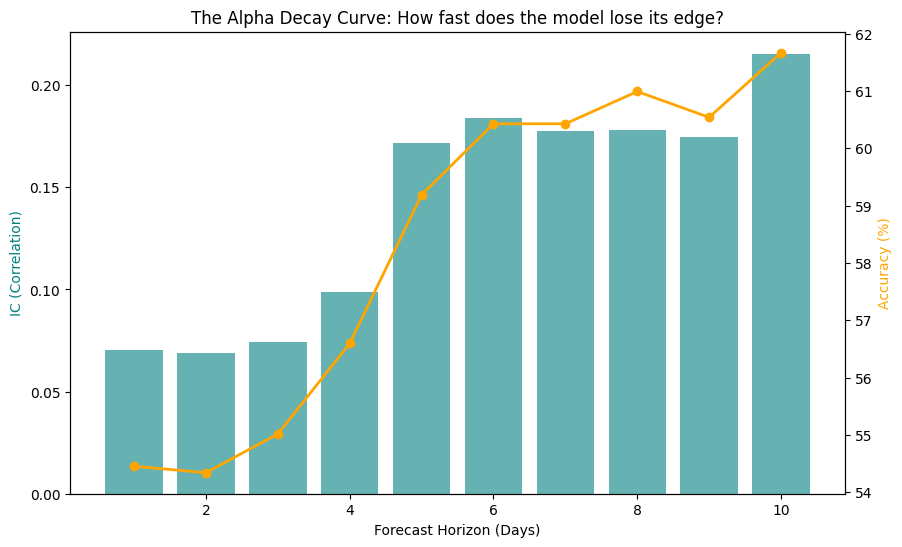

In [14]:
# PLOT DECAY
fig, ax1 = plt.subplots(figsize=(10, 6))
days = range(1, MAX_HORIZON + 1)

# IC Bar Chart
ax1.bar(days, ics, color='teal', alpha=0.6, label='Information Coeff (IC)')
ax1.set_ylabel('IC (Correlation)', color='teal')
ax1.set_xlabel('Forecast Horizon (Days)')
ax1.axhline(0, color='black', linewidth=0.5)

# Accuracy Line Chart
ax2 = ax1.twinx()
ax2.plot(days, np.array(accuracies)*100, color='orange', marker='o', linewidth=2, label='Accuracy')
ax2.set_ylabel('Accuracy (%)', color='orange')

plt.title('The Alpha Decay Curve: How fast does the model lose its edge?')
plt.show()


🎲 Running Monte Carlo Simulation (Risk Analysis)...


100%|██████████| 50/50 [00:04<00:00, 11.43it/s]


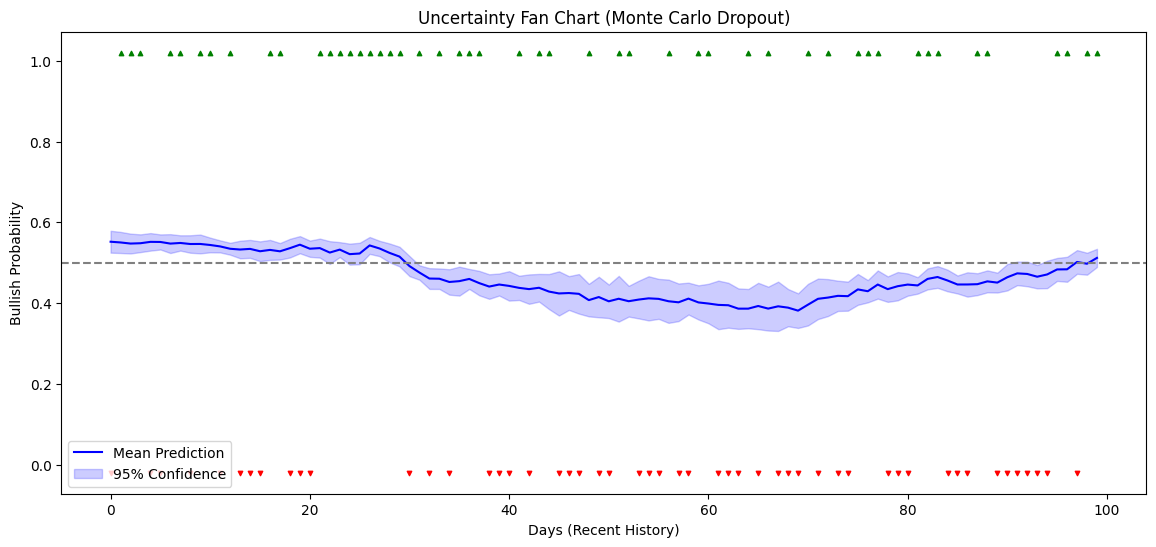

In [15]:
# ==========================================
# 6. ANALYSIS II: UNCERTAINTY (Monte Carlo Dropout)
# ==========================================
# We focus on Day 1 (Immediate Forecast) for this Risk Analysis
print("\n🎲 Running Monte Carlo Simulation (Risk Analysis)...")

def predict_uncertainty(model, X, n_iter=50):
    # Force Training=True to enable Dropout at inference time
    preds_mc = []
    for _ in tqdm(range(n_iter)):
        # We only care about the first column (Day 1 forecast) for this chart
        p = model(X, training=True)[:, 0]
        preds_mc.append(p)

    preds_mc = np.array(preds_mc) # Shape: (n_iter, Samples)

    return preds_mc.mean(axis=0), preds_mc.std(axis=0)

# Run on the last 100 days of test set
zoom = 100
X_zoom = X_test[-zoom:]
y_zoom = y_test[-zoom:, 0] # Actual Day 1 outcome

mc_mean, mc_std = predict_uncertainty(model, X_zoom)

# PLOT FAN CHART
plt.figure(figsize=(14, 6))
indices = range(len(mc_mean))

# Mean Prediction
plt.plot(indices, mc_mean, color='blue', label='Mean Prediction')

# Confidence Interval (Mean +/- 1.96 Std)
lower = np.maximum(0, mc_mean - 1.96 * mc_std)
upper = np.minimum(1, mc_mean + 1.96 * mc_std)
plt.fill_between(indices, lower, upper, color='blue', alpha=0.2, label='95% Confidence')

# Actual Outcomes (Dots)
# Green Dot = Price went up, Red Dot = Price went down
# We place dots at 1.05 (Up) or -0.05 (Down) for visibility
for i, val in enumerate(y_zoom):
    if val == 1:
        plt.scatter(i, 1.02, color='green', s=10, marker='^')
    else:
        plt.scatter(i, -0.02, color='red', s=10, marker='v')

plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Uncertainty Fan Chart (Monte Carlo Dropout)')
plt.ylabel('Bullish Probability')
plt.xlabel('Days (Recent History)')
plt.legend(loc='lower left')
plt.show()


🔥 Generating Term Structure Heatmap...


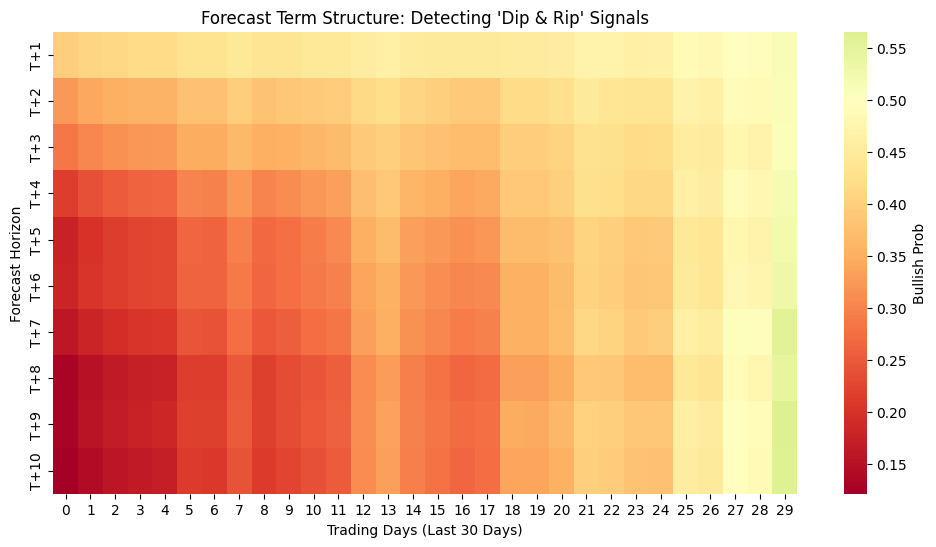

In [16]:
# ==========================================
# 7. ANALYSIS III: TERM STRUCTURE HEATMAP
# ==========================================
# Visualize the changing narrative over horizons
print("\n🔥 Generating Term Structure Heatmap...")

# Take last 30 days of predictions
heatmap_data = preds[-30:].T # Shape: (10 Horizons, 30 Days)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0.5,
            yticklabels=[f"T+{i}" for i in range(1, 11)],
            cbar_kws={'label': 'Bullish Prob'})

plt.title("Forecast Term Structure: Detecting 'Dip & Rip' Signals")
plt.xlabel("Trading Days (Last 30 Days)")
plt.ylabel("Forecast Horizon")
plt.show()